# Examen Final - Modelos para pronósticos no lineales

- Stonks
- Aissa Berenice
- Tiburivan
- Colomé

## Definición del problema

El objetivo es predecir los minutos de LeBron James en los partidos de temporada regular de los Lakers usando datos históricos y variables exógenas. El análisis se expandirá a tres temporadas (2023-24, 2024-25 y 2025-26) para obtener un modelo más robusto y una validación realista.

## Data Loading y Feature Engineering

Aquí se cargan las tres temporadas completas y se unen los datos del calendario de los Lakers con los minutos de LeBron y Luka. También se crean variables adicionales para que el modelo pueda aprender patrones temporales.
- Se limpian y convierten los minutos a valores numéricos.
- Se agregan variables de descanso, back-to-back y larga recuperación.
- Se crean lags, medias móviles y desviaciones estándar móviles (ventanas deslizantes) de minutos de LeBron.
- Se incluyen variables exógenas de Luka, local/visitante y estadísticas de equipo.


In [11]:
import pandas as pd
import time
from nba_api.stats.endpoints import leaguegamefinder, playergamelog

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import plotly.graph_objects as go
import matplotlib.pyplot as plt

Esta visualización muestra cómo varían los minutos de LeBron y Luka a lo largo del tiempo, y marca los juegos consecutivos (back-to-back) donde la fatiga puede afectar las decisiones de minutos.

Aquí se crean las variables de serie temporal y las ventanas deslizantes para capturar patrones en los minutos de LeBron.
- Lags: minutos de los partidos anteriores (1, 2 y 3 partidos atrás).
- Ventanas deslizantes: medias y desviaciones estándar móviles de 3 y 5 partidos para ver tendencias recientes.

In [12]:
# IDs oficiales de la NBA
ID_LAKERS = '1610612747'
ID_LEBRON = '2544'
ID_LUKA = '1629029'

seasons = ['2023-24', '2024-25', '2025-26']

def fetch_team_schedule(team_id, season):
    df = leaguegamefinder.LeagueGameFinder(
        team_id_nullable=team_id,
        season_nullable=season
    ).get_data_frames()[0]
    if 'SEASON_TYPE' in df.columns:
        df = df[df['SEASON_TYPE'] == 'Regular Season']
    return df[['GAME_ID', 'GAME_DATE', 'MATCHUP', 'SEASON_ID', 'WL', 'PTS', 'REB', 'AST', 'PLUS_MINUS']].drop_duplicates()


def fetch_player_minutes(player_id, season):
    df = playergamelog.PlayerGameLog(player_id=player_id, season=season).get_data_frames()[0]
    if 'SEASON_TYPE' in df.columns:
        df = df[df['SEASON_TYPE'] == 'Regular Season']
    return df[['Game_ID', 'GAME_DATE', 'MATCHUP', 'MIN']].rename(columns={'Game_ID': 'GAME_ID'})

schedule_frames = []
lebron_frames = []
luka_frames = []

for season in seasons:
    time.sleep(0.6)
    schedule = fetch_team_schedule(ID_LAKERS, season)
    schedule['season'] = season
    schedule_frames.append(schedule)

    time.sleep(0.6)
    lebron = fetch_player_minutes(ID_LEBRON, season)
    lebron['season'] = season
    lebron = lebron.rename(columns={'MIN': 'MIN_LeBron'})
    lebron_frames.append(lebron)

    time.sleep(0.6)
    luka = fetch_player_minutes(ID_LUKA, season)
    luka['season'] = season
    luka = luka.rename(columns={'MIN': 'MIN_Luka'})
    luka_frames.append(luka)

lakers_games = pd.concat(schedule_frames, ignore_index=True)
lebron_log = pd.concat(lebron_frames, ignore_index=True)
luka_log = pd.concat(luka_frames, ignore_index=True)

# Unir calendario con los minutos de LeBron y Luka
# Usamos left join para conservar todos los partidos del equipo

df_ts = lakers_games.merge(lebron_log[['GAME_ID', 'MIN_LeBron']], on='GAME_ID', how='left')
df_ts = df_ts.merge(luka_log[['GAME_ID', 'MIN_Luka']], on='GAME_ID', how='left')

def clean_minutes(value):
    if pd.isna(value) or value == 0:
        return 0.0
    text = str(value)
    if ':' in text:
        minutes, seconds = text.split(':')
        return float(minutes) + float(seconds) / 60
    return float(text)

for col in ['MIN_LeBron', 'MIN_Luka']:
    df_ts[col] = df_ts[col].apply(clean_minutes)

df_ts['GAME_DATE'] = pd.to_datetime(df_ts['GAME_DATE'])
df_ts = df_ts.sort_values('GAME_DATE').reset_index(drop=True)

df_ts['Days_Since_Last_Game'] = df_ts['GAME_DATE'].diff().dt.days.fillna(0).astype(int)
df_ts['Rest_Days_Capped'] = df_ts['Days_Since_Last_Game'].clip(upper=10)
df_ts['Is_B2B'] = (df_ts['Days_Since_Last_Game'] == 1).astype(int)
df_ts['Is_Long_Rest'] = (df_ts['Days_Since_Last_Game'] >= 10).astype(int)
df_ts['Luka_Playing'] = (df_ts['MIN_Luka'] > 0).astype(int)
df_ts['Home_Away'] = df_ts['MATCHUP'].apply(lambda x: 1 if 'vs.' in x else 0)
df_ts['Opponent'] = df_ts['MATCHUP'].apply(lambda x: x.split()[-1])
df_ts['Season_Month'] = df_ts['GAME_DATE'].dt.month

df_ts['MIN_LeBron_Lag1'] = df_ts['MIN_LeBron'].shift(1)
df_ts['MIN_LeBron_Lag2'] = df_ts['MIN_LeBron'].shift(2)
df_ts['MIN_LeBron_Lag3'] = df_ts['MIN_LeBron'].shift(3)
df_ts['MIN_Luka_Lag1'] = df_ts['MIN_Luka'].shift(1)
df_ts['MIN_Luka_Lag2'] = df_ts['MIN_Luka'].shift(2)
df_ts['Rolling_3_Mean_LeBron'] = df_ts['MIN_LeBron'].rolling(3).mean().shift(1)
df_ts['Rolling_5_Mean_LeBron'] = df_ts['MIN_LeBron'].rolling(5).mean().shift(1)
df_ts['Rolling_3_STD_LeBron'] = df_ts['MIN_LeBron'].rolling(3).std().shift(1).fillna(0)
df_ts['Rolling_5_STD_LeBron'] = df_ts['MIN_LeBron'].rolling(5).std().shift(1).fillna(0)
df_ts['Season_Code'] = df_ts['season'].astype('category').cat.codes

print(df_ts[['season', 'GAME_DATE', 'MATCHUP', 'MIN_LeBron', 'MIN_Luka', 'Is_B2B', 'Luka_Playing']].head(10))

# Mantener solo filas con lags válidos
print('Total partidos cargados:', len(df_ts))

df_ts = df_ts.dropna(subset=[
    'MIN_LeBron_Lag1',
    'MIN_LeBron_Lag2',
    'MIN_LeBron_Lag3',
    'MIN_Luka_Lag1',
    'MIN_Luka_Lag2',
    'Rolling_5_Mean_LeBron'
])

    season  GAME_DATE      MATCHUP  MIN_LeBron  MIN_Luka  Is_B2B  Luka_Playing
0  2023-24 2023-10-07    LAL @ GSW         0.0       0.0       0             0
1  2023-24 2023-10-09  LAL vs. BKN         0.0       0.0       0             0
2  2023-24 2023-10-11  LAL vs. SAC         0.0       0.0       0             0
3  2023-24 2023-10-13  LAL vs. GSW         0.0       0.0       0             0
4  2023-24 2023-10-15  LAL vs. MIL         0.0       0.0       0             0
5  2023-24 2023-10-19  LAL vs. PHX         0.0       0.0       0             0
6  2023-24 2023-10-24    LAL @ DEN        29.0       0.0       0             0
7  2023-24 2023-10-26  LAL vs. PHX        35.0       0.0       0             0
8  2023-24 2023-10-29    LAL @ SAC        39.0       0.0       0             0
9  2023-24 2023-10-30  LAL vs. ORL        33.0       0.0       1             0
Total partidos cargados: 286


Esta visualización muestra cómo varían los minutos de LeBron y Luka a lo largo del tiempo, y marca los juegos consecutivos (back-to-back) donde la fatiga puede influir en la carga de minutos.

In [13]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_ts['GAME_DATE'],
    y=df_ts['MIN_Luka'],
    mode='lines',
    name='Minutos Luka',
    line=dict(color='royalblue', width=2),
    hovertemplate='<b>Fecha:</b> %{x}<br><b>Luka:</b> %{y:.1f} min<extra></extra>'
))

fig.add_trace(go.Scatter(
    x=df_ts['GAME_DATE'],
    y=df_ts['MIN_LeBron'],
    mode='lines+markers',
    name='Minutos LeBron',
    line=dict(color='purple', width=3),
    marker=dict(size=6, color='gold')
))

fig.add_trace(go.Bar(
    x=df_ts[df_ts['Is_B2B'] == 1]['GAME_DATE'],
    y=[55] * len(df_ts[df_ts['Is_B2B'] == 1]),
    name='Back-to-Back',
    marker_color='rgba(255, 0, 0, 0.18)',
    width=86400000 * 0.7,
    hoverinfo='skip'
))

fig.update_layout(
    title='Minutos de LeBron y Luka en temporadas 2023-24 a 2025-26',
    xaxis_title='Fecha',
    yaxis_title='Minutos',
    template='plotly_white',
    hovermode='x unified',
    yaxis=dict(range=[0, 55]),
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()

Verificamos si la serie de minutos de LeBron es estacionaria con el test ADF. Luego graficamos la autocorrelación (ACF) y la autocorrelación parcial (PACF) para ver si los valores pasados ayudan a predecir los futuros.


Verificamos si la serie de minutos de LeBron es estacionaria y revisamos la autocorrelación para entender si los valores pasados ayudan a predecir los futuros.

ADF Test para MIN_LeBron
ADF Statistic: -5.0504
p-value: 0.0000
Número de lags usados: 2
Número de observaciones usadas: 278


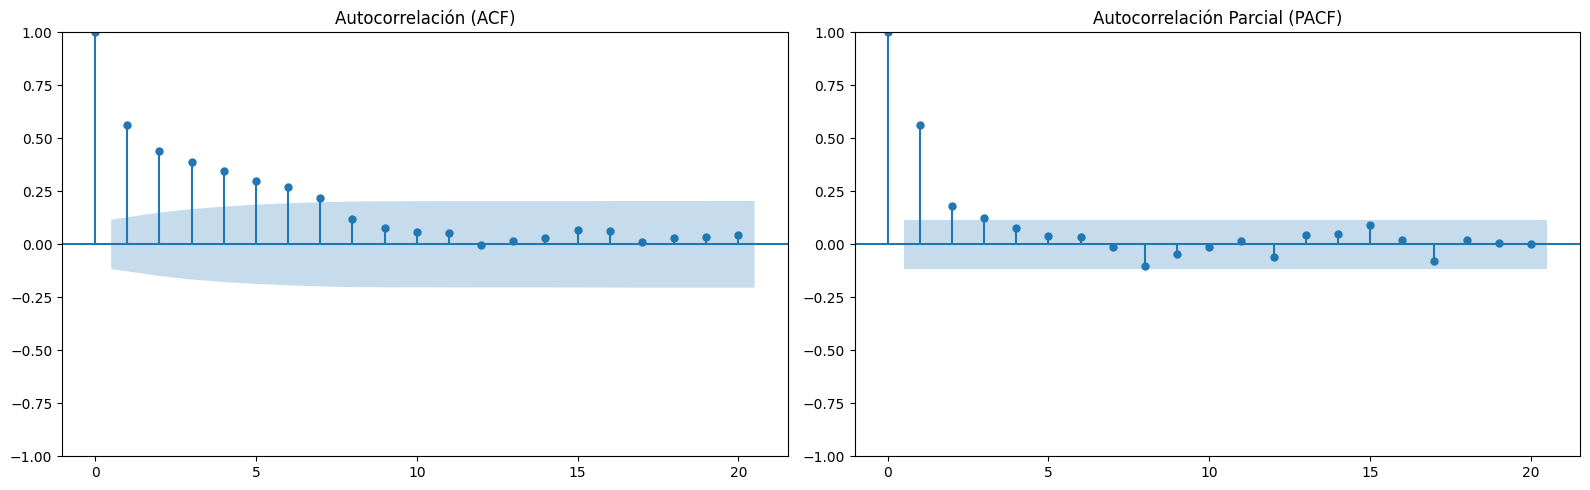

In [14]:
print('ADF Test para MIN_LeBron')
result = adfuller(df_ts['MIN_LeBron'].dropna())
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4f}')
print('Número de lags usados:', result[2])
print('Número de observaciones usadas:', result[3])


def autocorrelation_plots(timeseries):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    plot_acf(timeseries.dropna(), ax=ax1, lags=20, title='Autocorrelación (ACF)')
    plot_pacf(timeseries.dropna(), ax=ax2, lags=20, title='Autocorrelación Parcial (PACF)', method='ywm')
    plt.tight_layout()
    plt.show()

autocorrelation_plots(df_ts['MIN_LeBron'])

## Escalamiento y división temporal

Aquí se eligen las variables que entran al modelo y se separan los partidos de entrenamiento (temporadas 2023-24 y 2024-25) de la temporada de prueba (2025-26). Los datos se escalan con MinMaxScaler para que la red neuronal entrene mejor.


In [15]:
feature_columns = [
    'MIN_LeBron_Lag1',
    'MIN_LeBron_Lag2',
    'MIN_LeBron_Lag3',
    'MIN_Luka',
    'MIN_Luka_Lag1',
    'MIN_Luka_Lag2',
    'Rolling_3_Mean_LeBron',
    'Rolling_5_Mean_LeBron',
    'Rolling_3_STD_LeBron',
    'Rolling_5_STD_LeBron',
    'Days_Since_Last_Game',
    'Rest_Days_Capped',
    'Is_B2B',
    'Is_Long_Rest',
    'Luka_Playing',
    'Home_Away',
    'Season_Month',
    'Season_Code',
    'PTS',
    'REB',
    'AST',
    'PLUS_MINUS'
]

df_model = df_ts[['GAME_DATE', 'season', 'MIN_LeBron'] + feature_columns].copy()

train = df_model[df_model['season'] != '2025-26'].reset_index(drop=True)
test = df_model[df_model['season'] == '2025-26'].reset_index(drop=True)

print('Entrenamiento:', len(train), 'partidos')
print('Prueba:', len(test), 'partidos')

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train = scaler_x.fit_transform(train[feature_columns])
X_test = scaler_x.transform(test[feature_columns])

y_train = scaler_y.fit_transform(train[['MIN_LeBron']])
y_test = scaler_y.transform(test[['MIN_LeBron']])

Entrenamiento: 183 partidos
Prueba: 98 partidos


## Arquitectura del Modelo
Se usa un modelo secuencial con capas densas y una capa de dropout. El modelo recibe variables exógenas y de serie temporal, aprende patrones en los minutos pasados y predice los minutos futuros de LeBron. Se usa EarlyStopping para evitar sobreajuste.


## Entrenamiento del Modelo

In [16]:
model_ffnn = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='linear')
])

model_ffnn.compile(optimizer='adam', loss='mse', metrics=['mae'])
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model_ffnn.fit(
    X_train,
    y_train,
    epochs=120,
    batch_size=8,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stop],
    verbose=1
)

y_pred_scaled = model_ffnn.predict(X_test)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

y_real = scaler_y.inverse_transform(y_test)

Epoch 1/120


c:\Users\colom\Documents\iteso\8vo\modelos_no_lineales\examen_final_peter\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.1752 - mae: 0.3492 - val_loss: 0.0934 - val_mae: 0.2504
Epoch 2/120
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1082 - mae: 0.2626 - val_loss: 0.0753 - val_mae: 0.2419
Epoch 3/120
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0892 - mae: 0.2324 - val_loss: 0.0799 - val_mae: 0.2432
Epoch 4/120
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0817 - mae: 0.2214 - val_loss: 0.0792 - val_mae: 0.2408
Epoch 5/120
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0737 - mae: 0.2030 - val_loss: 0.0777 - val_mae: 0.2400
Epoch 6/120
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0793 - mae: 0.2245 - val_loss: 0.0756 - val_mae: 0.2385
Epoch 7/120
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0808 - mae: 0.2149 - val_loss: 0.0708 - val_mae: 0.2260
Epoch 8/120
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0808 - mae: 0.2176 - val_loss: 0.0692 - val_mae: 0.2239
Epoch 9/120
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0801 - mae: 0.2

Evaluación del modelo FFNN
MSE: 171.747
MAE: 9.132
R2: 0.362

Baseline (lag 1)
MSE baseline: 168.102
MAE baseline: 6.633


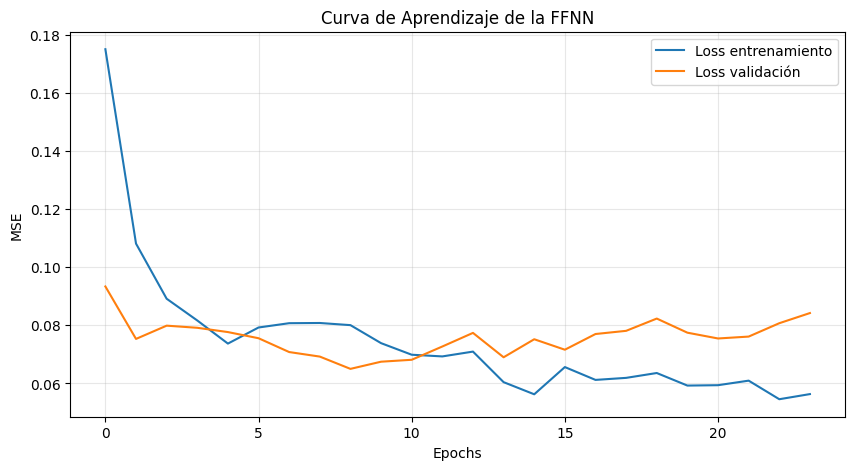

In [17]:
baseline_pred = test['MIN_LeBron_Lag1'].values.reshape(-1, 1)
baseline_mse = mean_squared_error(test['MIN_LeBron'], baseline_pred)
baseline_mae = mean_absolute_error(test['MIN_LeBron'], baseline_pred)

mse = mean_squared_error(y_real, y_pred)
mae = mean_absolute_error(y_real, y_pred)
r2 = r2_score(y_real, y_pred)

print('Evaluación del modelo FFNN')
print(f'MSE: {mse:.3f}')
print(f'MAE: {mae:.3f}')
print(f'R2: {r2:.3f}')
print('\nBaseline (lag 1)')
print(f'MSE baseline: {baseline_mse:.3f}')
print(f'MAE baseline: {baseline_mae:.3f}')

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.title('Curva de Aprendizaje de la FFNN')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Pronóstico

Comparamos la predicción de la FFNN con los minutos reales de LeBron en la temporada 2025-26.

In [18]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=test['GAME_DATE'],
    y=test['MIN_LeBron'],
    mode='lines+markers',
    name='Minutos Reales',
    line=dict(color='purple', width=3),
    marker=dict(size=6)
))

fig.add_trace(go.Scatter(
    x=test['GAME_DATE'],
    y=y_pred.flatten(),
    mode='lines+markers',
    name='Predicción FFNN',
    line=dict(color='gold', width=3, dash='dash'),
    marker=dict(size=6, symbol='x')
))

fig.update_layout(
    title='Pronóstico de minutos de LeBron James (temporada 2025-26)',
    xaxis_title='Fecha',
    yaxis_title='Minutos',
    template='plotly_white',
    hovermode='x unified',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()

## Conclusiones
- Amplia el análisis a tres temporadas completas para tener más datos reales.
- Combina el calendario de los Lakers con los minutos de LeBron y de Luka para cada partido.
- Convierte y limpia los minutos en formato numérico.
- Agrega variables exógenas: minutos de Luka, lags de Luka, presencia de Luka, local/visitante, mes de temporada, código de temporada, estadísticas de equipo (PTS, REB, AST, PLUS_MINUS), días de descanso y back-to-back.
- Agrega variables de series temporales: lags de LeBron (1, 2 y 3 partidos) y ventanas móviles deslizantes de 3 y 5 partidos (medias y desviaciones estándar).
- Todas estas variables entran al modelo FFNN.
- Se entrena con las temporadas 2023-24 y 2024-25 y se valida en la temporada 2025-26.
- Se usa MinMaxScaler para escalar atributos y target.
- Se evalúa con MSE, MAE y R2, y se compara con un baseline simple.
- La gráfica final muestra el pronóstico del modelo frente a los minutos reales de LeBron.
### Cambios realizados
- Carga de datos de tres temporadas en lugar de una sola.
- Filtrado de partidos de temporada regular y limpieza de minutos con conversión numérica.
- Unión del calendario de Lakers con minutos de LeBron y Luka.
- Creación de variables exógenas: MIN_Luka, MIN_Luka_Lag1, MIN_Luka_Lag2, Luka_Playing, Home_Away, Season_Month, Season_Code, PTS, REB, AST, PLUS_MINUS, Days_Since_Last_Game, Rest_Days_Capped, Is_B2B, Is_Long_Rest.
- Creación de variables de serie temporal: MIN_LeBron_Lag1, MIN_LeBron_Lag2, MIN_LeBron_Lag3.
- Agregado de ventanas deslizantes (rolling window): Rolling_3_Mean_LeBron, Rolling_5_Mean_LeBron, Rolling_3_STD_LeBron, Rolling_5_STD_LeBron.
- Uso de un FFNN con entrada de múltiples variables y dropout para reducir sobreajuste.
- División temporal realista con entrenamiento en temporadas anteriores y prueba en 2025-26.
- Escalado de datos con MinMaxScaler.
- Evaluación cuantitativa con MSE, MAE y R2.
- Visualización del pronóstico contra los resultados reales.
